## Results of Host Prediction
### Dataset: BVBRC proteome, Virus Genus Split

**Classification**: Multi-class

**\# classes**: 8

**\# proteins in dataset** = 12,913

**\# train samples** = 6768

**\# validation samples** = 3072

**\# test samples** = 3072

In [1]:
import seaborn

In [2]:
seaborn.__version__

'0.13.2'

In [3]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../..']

In [4]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr
from sklearn.model_selection import train_test_split
from src.utils import utils, evaluation_utils, visualization_utils

In [5]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_prevalence_gte_onepercent.csv")
input_df = pd.read_csv(input_filepath)

In [89]:
def analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col):
    similarity_dfs = []
    n_classes = len(classes)
    for split_type, filepath in sequence_similarity_filepaths.items():
        similarity_df = pd.read_csv(filepath, index_col=0)
        similarity_df["split_type"] = split_type
        similarity_dfs.append(similarity_df)
    
    similarity_df = pd.concat(similarity_dfs)
    #similarity_df[["split_type", "virus_host_species_tax_id", "target_label", "similarity_score"]].groupby(["split_type","virus_host_species_tax_id", "target_label"]).max().reset_index()
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(n_classes, n_classes, figsize=(36, 36), sharex=True, sharey=True)
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=similarity_df["split_type"].nunique())
    
    for i, y_test_class in enumerate(classes):
        for j, y_train_class in enumerate(classes):
            ax = axs[i][j]
            sns.kdeplot(data=similarity_df[(similarity_df[label_col] == y_test_class) & (similarity_df["target_label"] == y_train_class)], x="similarity_score", hue="split_type", 
                        palette=color_palette, ax=ax,
                        linewidth=1.5)
            #ax.set_xlabel(f"Similarity w/ {y_train_class}", size=0, labelpad=0)
            ax.set_ylabel(f"{y_test_class}\n\nDensity", size=20)
            ax.set_title(f"Similarity w/\n{y_train_class}", size=20)
            ax.set_xlim(0.0, 1)
            plt.setp(ax.get_legend().get_texts(), fontsize=20)
            ax.get_legend().set_title("")

    return similarity_df

In [90]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    print(classes)
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(24, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)

    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    #sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False)
    sns.move_legend(axs[1], "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(axs[1].get_legend().get_texts(), fontsize=14)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

In [91]:
def macro_and_classwise_auprc_proteome_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    raw_results = []
    itr_col = "itr"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        raw_df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {raw_df.shape}")
        raw_df = raw_df[["protein_id_name", itr_col, y_true_col] + classes].merge(input_df[["proteome_id", "protein", "protein_id_name", "virus_host_species_tax_id", "virus_genus_tax_name"]], on="protein_id_name", how="left")
        raw_df["model"] = model
        raw_results.append(raw_df)
        df = raw_df[classes + ["proteome_id", "y_true", "itr"]]
        df = df.groupby(["proteome_id", "y_true", "itr"]).agg("mean").reset_index()
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(24, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "upper left", title=None, bbox_to_anchor=(1, 1))
    #sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return pd.concat(raw_results)

# Dataset: BV-BRC

In [92]:
classes = ["Human", "Chicken", "Pig", "Domestic cattle", "Norway rat", "Horse", "Wolf", "Boa"]
output_filepaths = {
    "BLAST-split[random]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/random_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "HAVEN-split[random]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528a/host_multi/random_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output_itr0.csv"),
    "BLAST-split[virus-genus]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "ProtT5-split[virus-genus]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260612a/host_multi/virus_genus_split/external/bvbrc_prott5_prot_t5_base_mt_uniref50_msl7141_fnn_2l_d768_lr3e-4_output.csv"),
    "HAVEN-split[virus-genus]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260611a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output.csv"),
    "BLAST-split[virus-species]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_species_host_species_vertebrates_t0.01_c8/20260604/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "ProtT5-split[virus-species]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_species_host_species_vertebrates_t0.01_c8/20260612b/host_multi/virus_species_split/external/bvbrc_prott5_prot_t5_base_mt_uniref50_msl7141_fnn_2l_d768_lr3e-4_output_itr0.csv"),
    "HAVEN-split[virus-species]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260611b/host_multi/virus_species_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-2_output_itr0.csv"),
}

## Protein-level Evaluation

['Human', 'Chicken', 'Pig', 'Domestic cattle', 'Norway rat', 'Horse', 'Wolf', 'Boa']
Read output BLAST-split[random]-label[host-species] = (1928, 14)
Read output HAVEN-split[random]-label[host-species] = (964, 11)
Read output BLAST-split[virus-genus]-label[host-species] = (2402, 14)
Read output ProtT5-split[virus-genus]-label[host-species] = (4156, 11)
Read output HAVEN-split[virus-genus]-label[host-species] = (1037, 11)
Read output BLAST-split[virus-species]-label[host-species] = (11145, 14)


/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set

Read output ProtT5-split[virus-species]-label[host-species] = (932, 11)
Read output HAVEN-split[virus-species]-label[host-species] = (932, 11)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


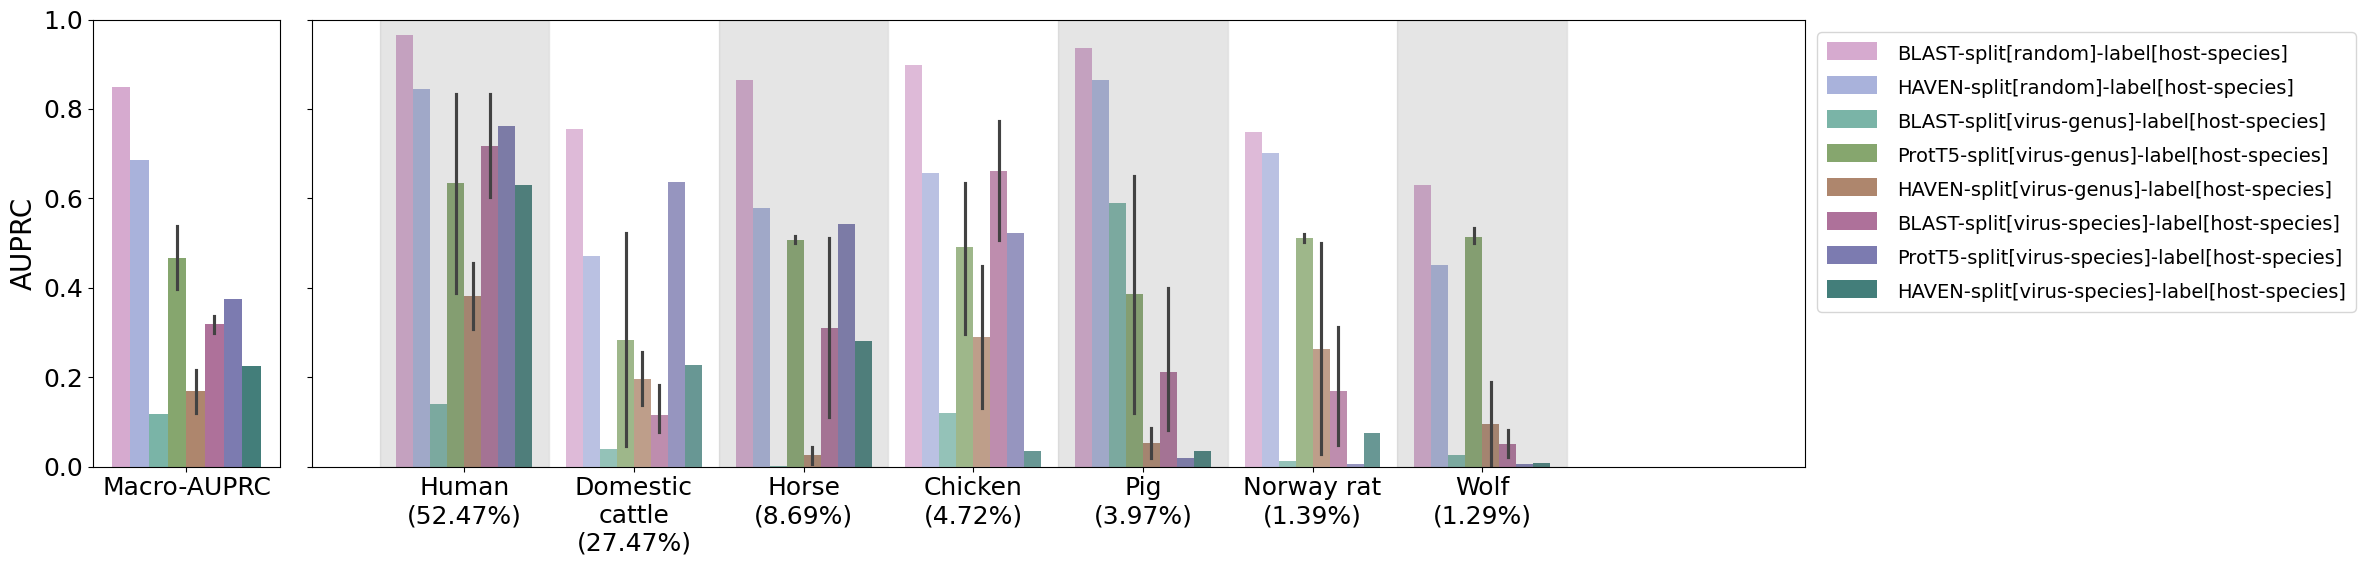

In [93]:
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes=classes, figure_output_filepath=None)

## Proteome-level Evaluation

Read output BLAST-split[random]-label[host-species] = (1928, 14)
Read output HAVEN-split[random]-label[host-species] = (964, 11)
Read output BLAST-split[virus-genus]-label[host-species] = (2402, 14)
Read output ProtT5-split[virus-genus]-label[host-species] = (4156, 11)
Read output HAVEN-split[virus-genus]-label[host-species] = (1037, 11)
Read output BLAST-split[virus-species]-label[host-species] = (11145, 14)
Read output ProtT5-split[virus-species]-label[host-species] = (932, 11)
Read output HAVEN-split[virus-species]-label[host-species] = (932, 11)


/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set

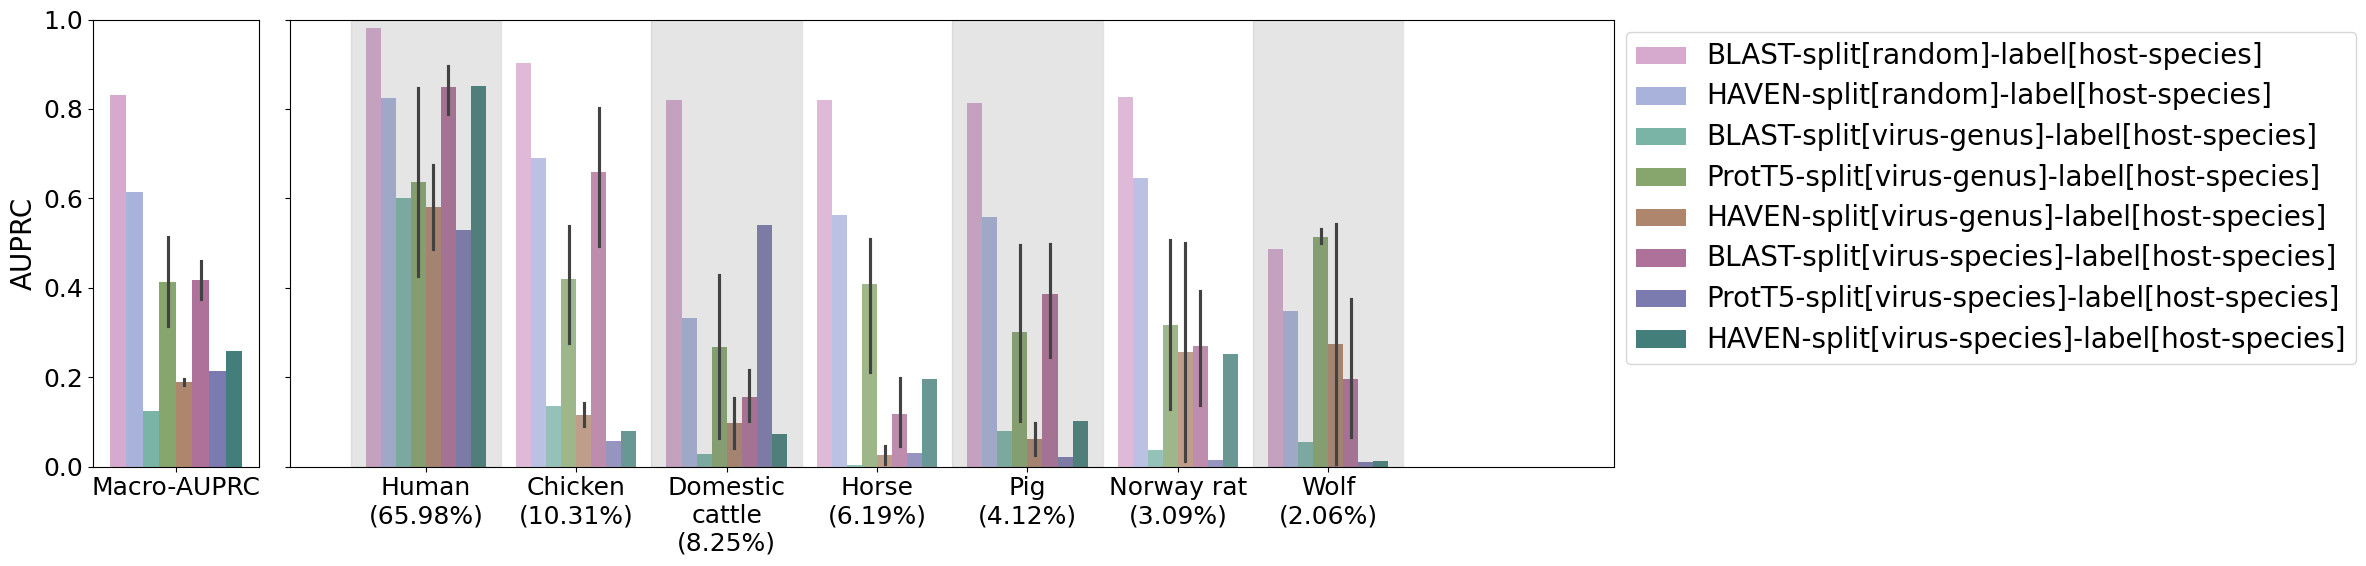

In [94]:
raw_results_df = macro_and_classwise_auprc_proteome_analysis(output_filepaths, classes, figure_output_filepath=None)

## Sequence Similarity

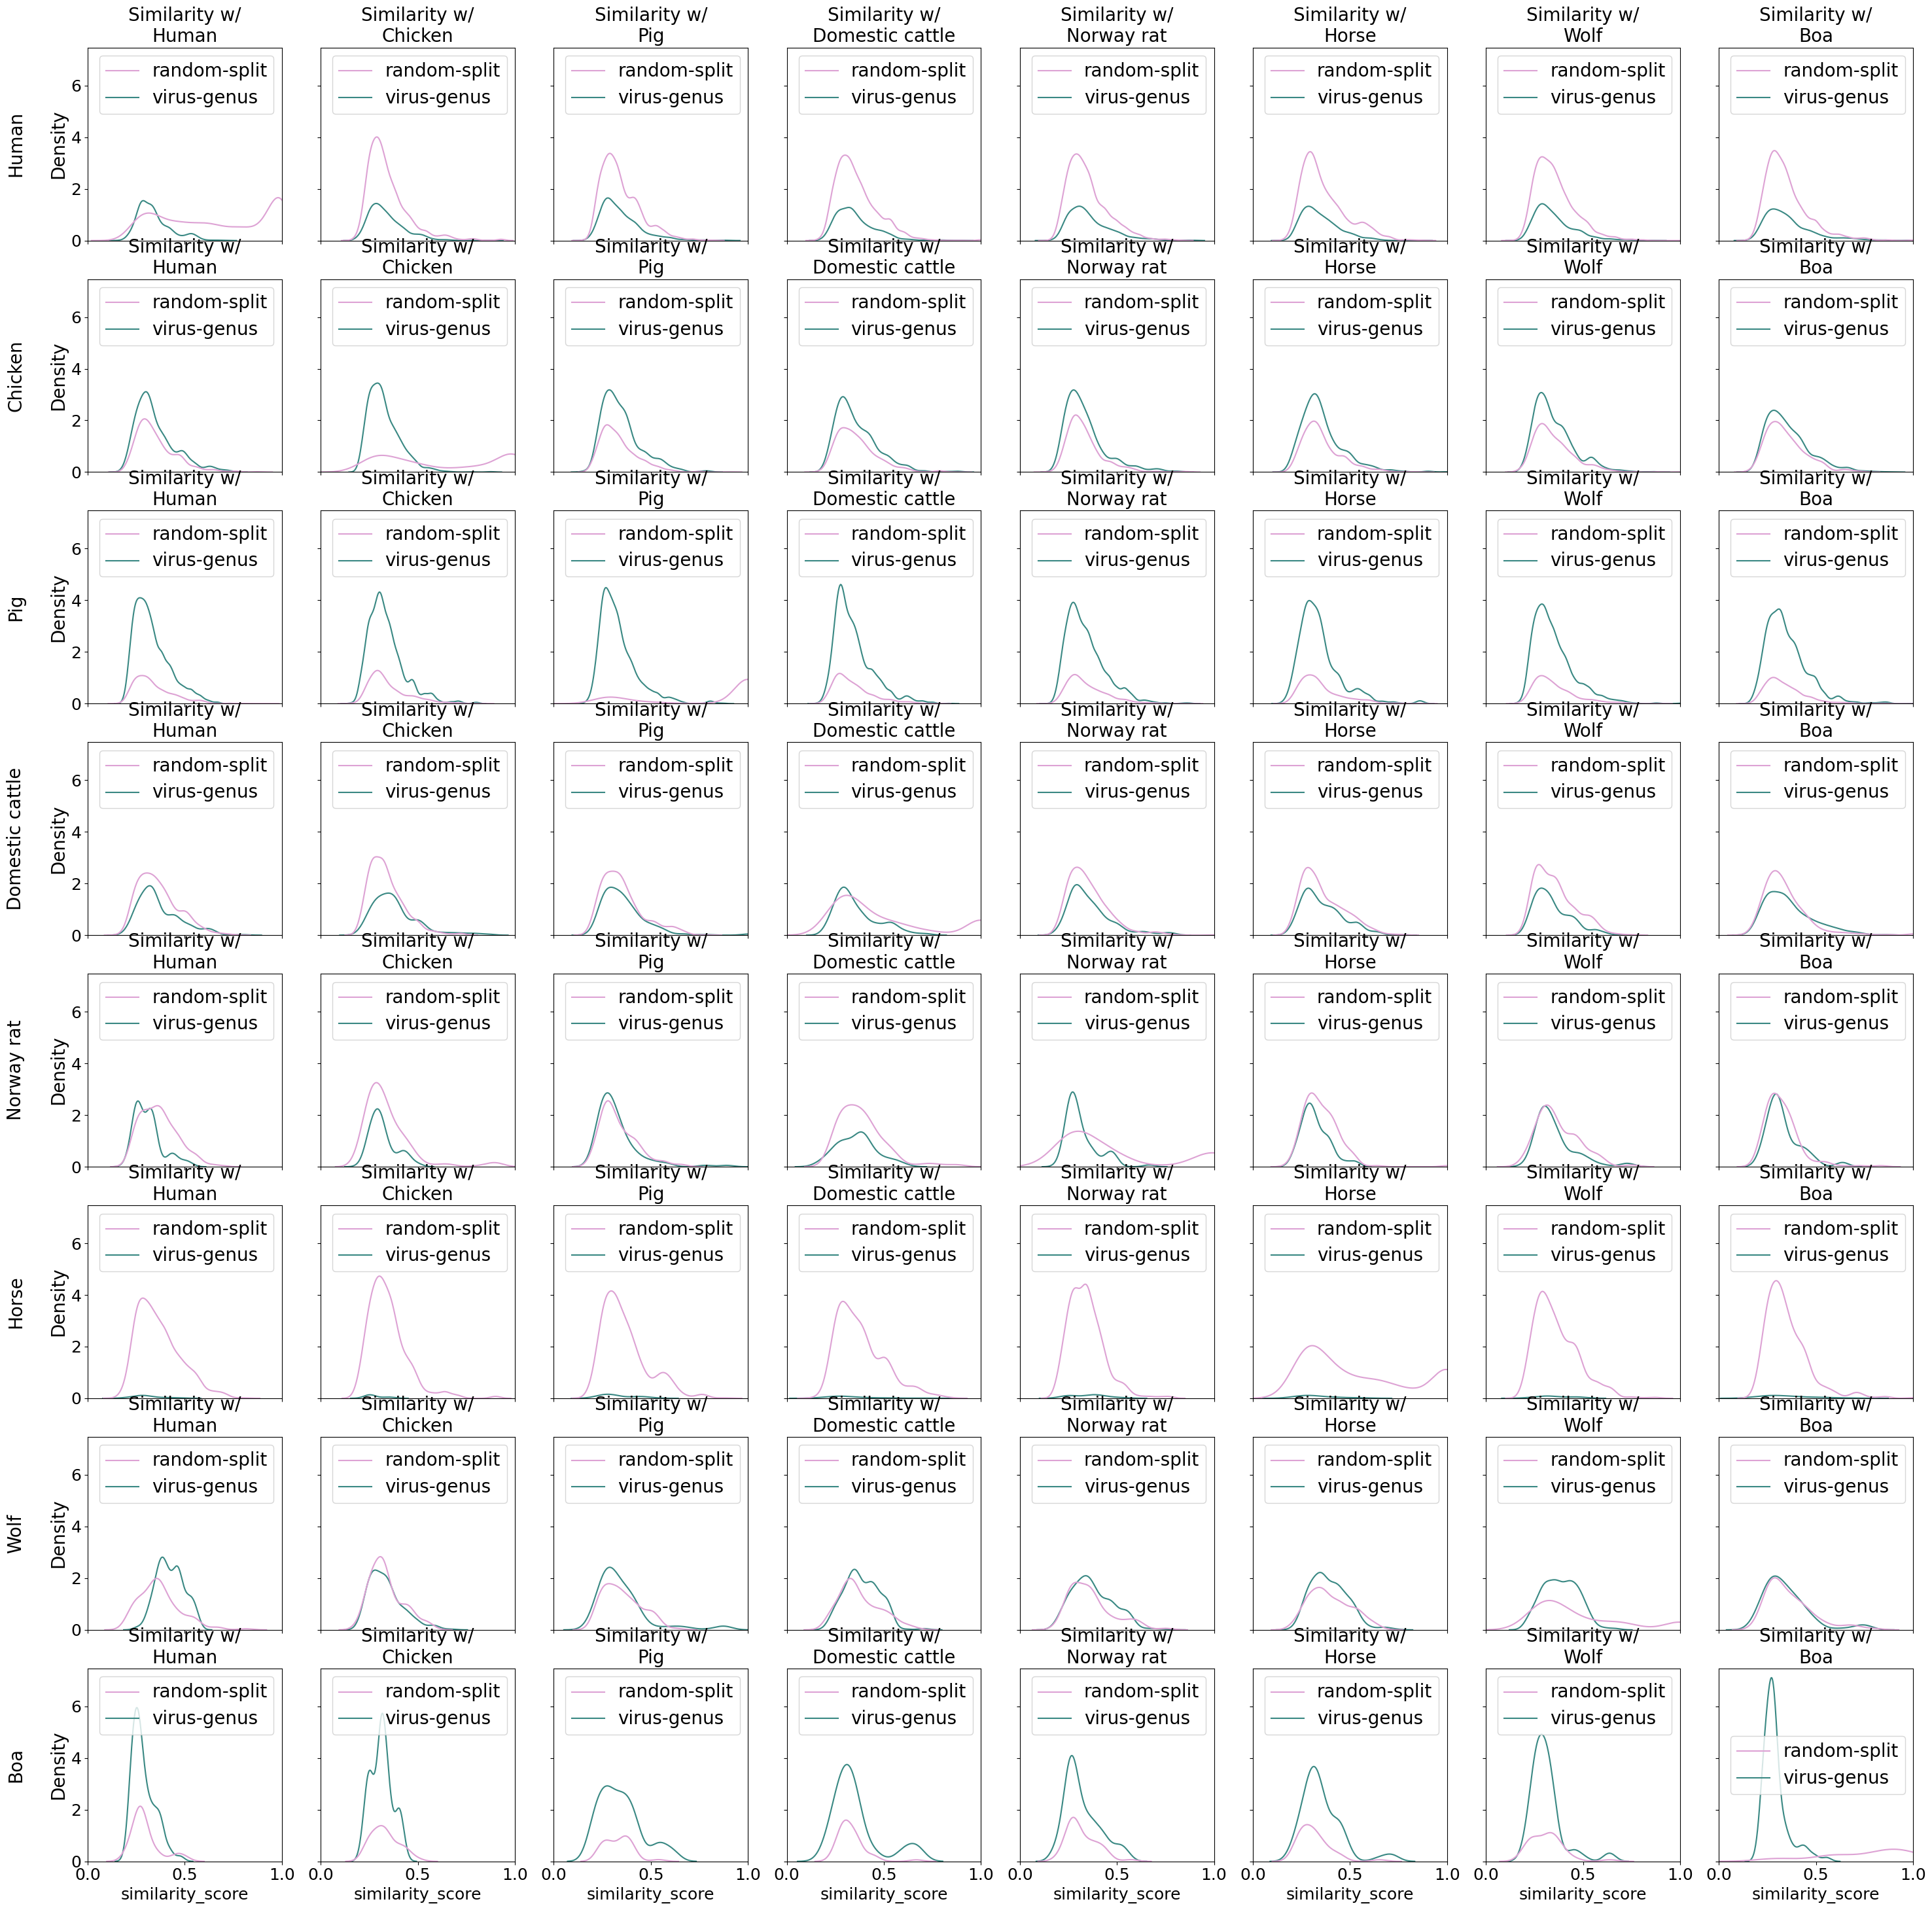

In [95]:
classes = ["Human", "Chicken", "Pig", "Domestic cattle", "Norway rat", "Horse", "Wolf", "Boa"]
sequence_similarity_filepaths = {
    "random-split": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/random_split/homology/virus_host_species_tax_id_multi_blast_blast_similarity_scores.csv"),
    "virus-genus": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_similarity_scores.csv"),
}

similarity_df = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_species_tax_id")

In [96]:
similarity_df[["split_type", "virus_host_species_tax_id", "target_label", "similarity_score"]].groupby(["split_type","virus_host_species_tax_id", "target_label"]).max().reset_index()

,split_type,virus_host_species_tax_id,target_label,similarity_score
0,random-split,Boa,Boa,1.00000
1,random-split,Boa,Chicken,0.50000
2,random-split,Boa,Domestic cattle,0.66667
3,random-split,Boa,Horse,0.65000
4,random-split,Boa,Human,0.50000
...,...,...,...,...
123,virus-genus,Wolf,Horse,0.73333
124,virus-genus,Wolf,Human,0.57198
125,virus-genus,Wolf,Norway rat,0.75000
126,virus-genus,Wolf,Pig,0.87500


# Dataset: UniRef90

['Human', 'Pig', 'Capybara', 'Red junglefowl', 'Himalayan marmot']
Read output BLAST-split[random]-label[host-species] = (6338, 11)
Read output HAVEN-split[random]-label[host-species] = (15845, 7)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


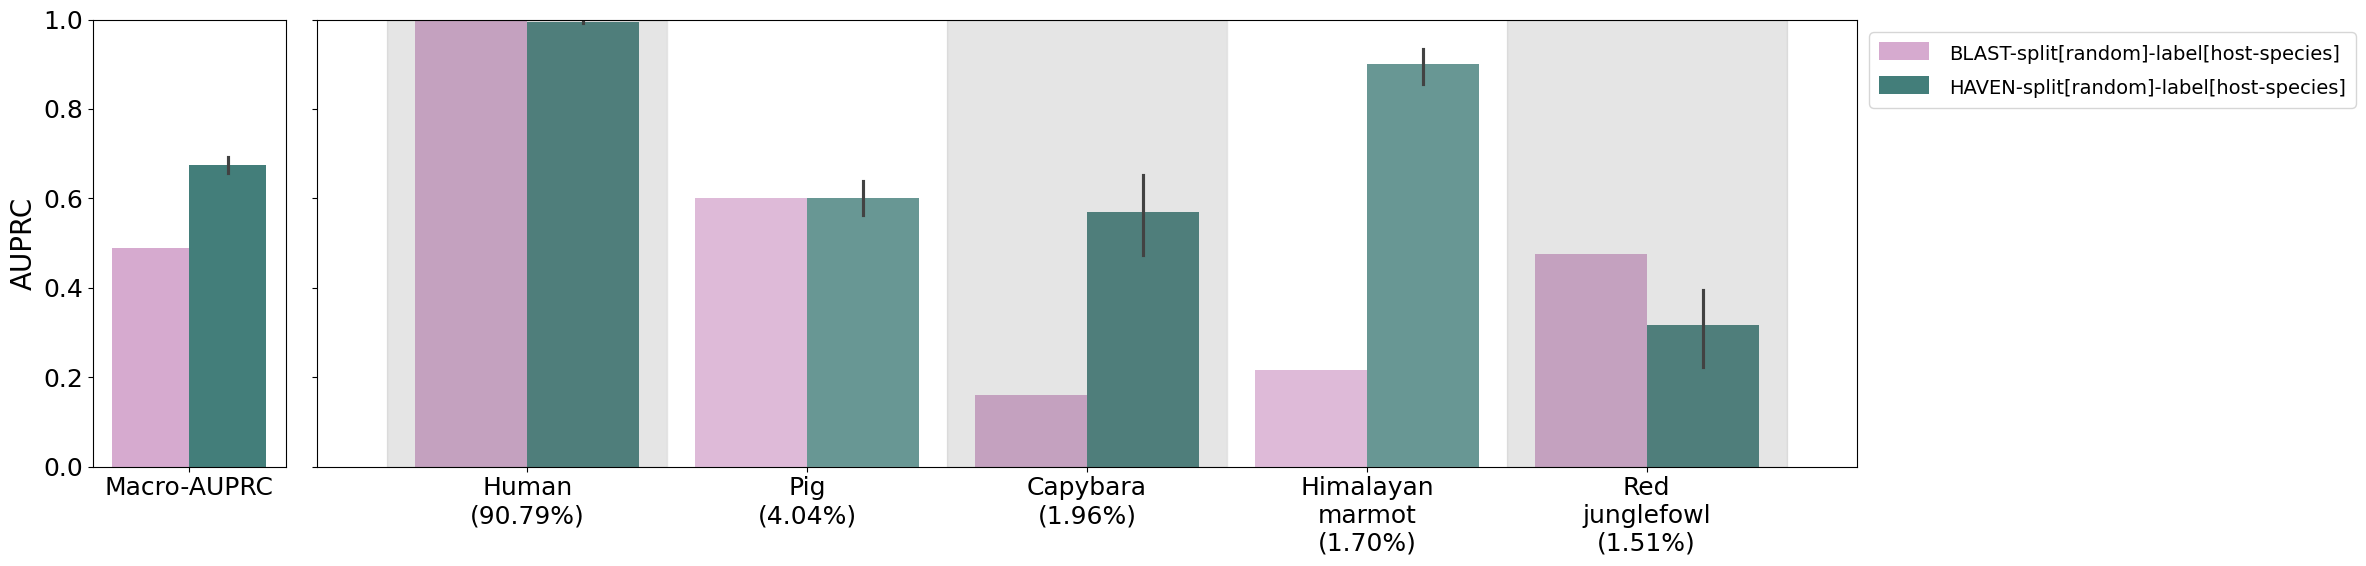

In [97]:
classes = ["Human", "Pig", "Capybara", "Red junglefowl", "Himalayan marmot"]
output_filepaths = {
    "BLAST-split[random]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260528/host_multi/random_split/homology/virus_host_tax_id_multi_blast_blast_output.csv"),
    "HAVEN-split[random]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20240826/host_multi/fine_tuning_hybrid_cls/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_hybrid_attention_msl256s64ae_bn_fnn_2l_d1024_lr1e-4_output.csv"),
}
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes, None)

In [14]:
x = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_virus_genus_host_species_vertebrates_non_idv_t0.01_c4_seq_len_in_99percentile/20260326/host_multi/virus_genus_split/homology/virus_host_tax_id_multi_blast_blast_output.csv"), index_col=0)
x

,uniref90_id,virus_host_tax_id,virus_name_genus,seq,Human,Pig,Domestic cattle,Red junglefowl,y_true,itr
24,UniRef90_A0A7M1VCS1,3,Gammacoronavirus,MLDFEVIIETGQQIIQQISFNLQHISSVLNTELFDPFEVCVYRGGN...,0.266941,0.260924,0.217908,0.254227,Red junglefowl,0
25,UniRef90_A0A7M1VFJ3,3,Gammacoronavirus,MSVTPLLLVTLLFALCSAALYDNNSYVYYYQSAFRPSNGWHLHGGA...,0.337539,0.198483,0.224395,0.239583,Red junglefowl,0
59,UniRef90_A0A386BX41,3,Gammacoronavirus,YGSYHPQCVFRPETINNGLWFNSQSVSLAYGPLQGGCKQSVFSNRA...,0.199167,0.290216,0.329234,0.181383,Red junglefowl,0
61,UniRef90_A0A386BXA1,1,Gammacoronavirus,MLGKSLFIVTLLFALCSANLFDNNQTVYYYQSAFRPPNGWHMHGGA...,NaN,0.269880,0.428386,0.301734,Human,0
80,UniRef90_A0A386BXY6,3,Gammacoronavirus,YGSYHQQCVFRPETINNGLWINSQCASLAYGPLQGGCKQSVFSNRA...,0.212947,0.215345,0.317248,0.254460,Red junglefowl,0
...,...,...,...,...,...,...,...,...,...,...
46414,UniRef90_A0A158WY96,1,Parechovirus,NSSSPNKVHCIVQGRLGDDAKFFCPTGSLVSFQNSWGSQMDLTDPL...,0.304734,0.235993,0.236879,0.222394,Human,4
46415,UniRef90_A0A158WYC0,1,Parechovirus,LTSAQDEGPLGGEKPNYFLNFRAINVDIFTVSHTKVDNIFGRAWFS...,NaN,0.275954,0.365171,0.358875,Human,4
46416,UniRef90_A0A158WZ44,1,Parechovirus,SSSPSSVHCIVQGRLGDDAKFFCPAGSIVTFQNSWGSQMDLTDPLC...,NaN,0.292831,0.422130,0.285039,Human,4
46417,UniRef90_A0A158WZ60,1,Parechovirus,NGNLWRSQLTFPKQGHGMLSQFFAYFTGELNIHILYMASSGFLRVA...,0.212014,0.251766,0.244024,0.292197,Human,4


['Human', 'Red junglefowl', 'Pig', 'Domestic cattle']
Read output BLAST-split[virus-genus]-label[host-species] = (44793, 10)
Read output HAVEN-split[virus-genus]-label[host-species] = (18473, 7)
Read output ProtT5-split[virus-genus]-label[host-species] = (2095, 7)


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


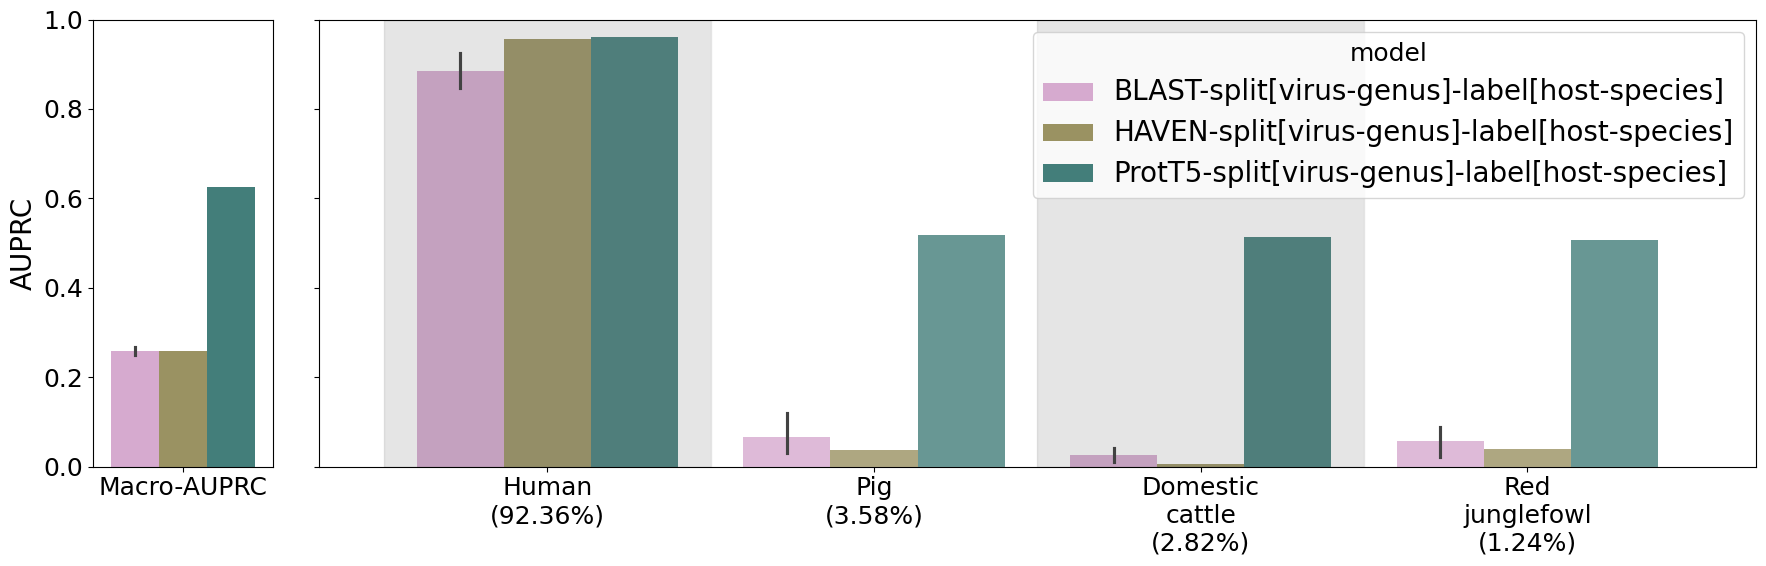

In [49]:
output_filepaths = {
    #"BLAST-split[random]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260528/host_multi/random_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "BLAST-split[virus-genus]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_virus_genus_host_species_vertebrates_non_idv_t0.01_c4_seq_len_in_99percentile/20260326/host_multi/virus_genus_split/homology/virus_host_tax_id_multi_blast_blast_output.csv"),
    "HAVEN-split[virus-genus]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output_itr0.csv"),
    "ProtT5-split[virus-genus]-label[host-species]": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260611/host_multi/virus_genus_split/external/uniref90_prott5_prot_t5_base_mt_uniref50_msl2048_fnn_2l_d768_lr3e-4_output_itr0.csv")
}

classes = ["Human", "Red junglefowl", "Pig", "Domestic cattle"]
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes, None)

In [24]:
auprc_results_df

,class,auprc,model,itr
0,Human (82.19%),0.849814,BLAST-split[virus-genus]-label[host-species],0
1,Red junglefowl (8.57%),0.112189,BLAST-split[virus-genus]-label[host-species],0
2,Pig (4.71%),0.070808,BLAST-split[virus-genus]-label[host-species],0
3,Domestic cattle (4.53%),0.044176,BLAST-split[virus-genus]-label[host-species],0
4,Macro-AUPRC,0.269247,BLAST-split[virus-genus]-label[host-species],0
5,Human (82.19%),0.833141,BLAST-split[virus-genus]-label[host-species],1
6,Red junglefowl (8.57%),0.043090,BLAST-split[virus-genus]-label[host-species],1
7,Pig (4.71%),0.164189,BLAST-split[virus-genus]-label[host-species],1
8,Domestic cattle (4.53%),0.026874,BLAST-split[virus-genus]-label[host-species],1
9,Macro-AUPRC,0.266824,BLAST-split[virus-genus]-label[host-species],1


## Sequence Similarity

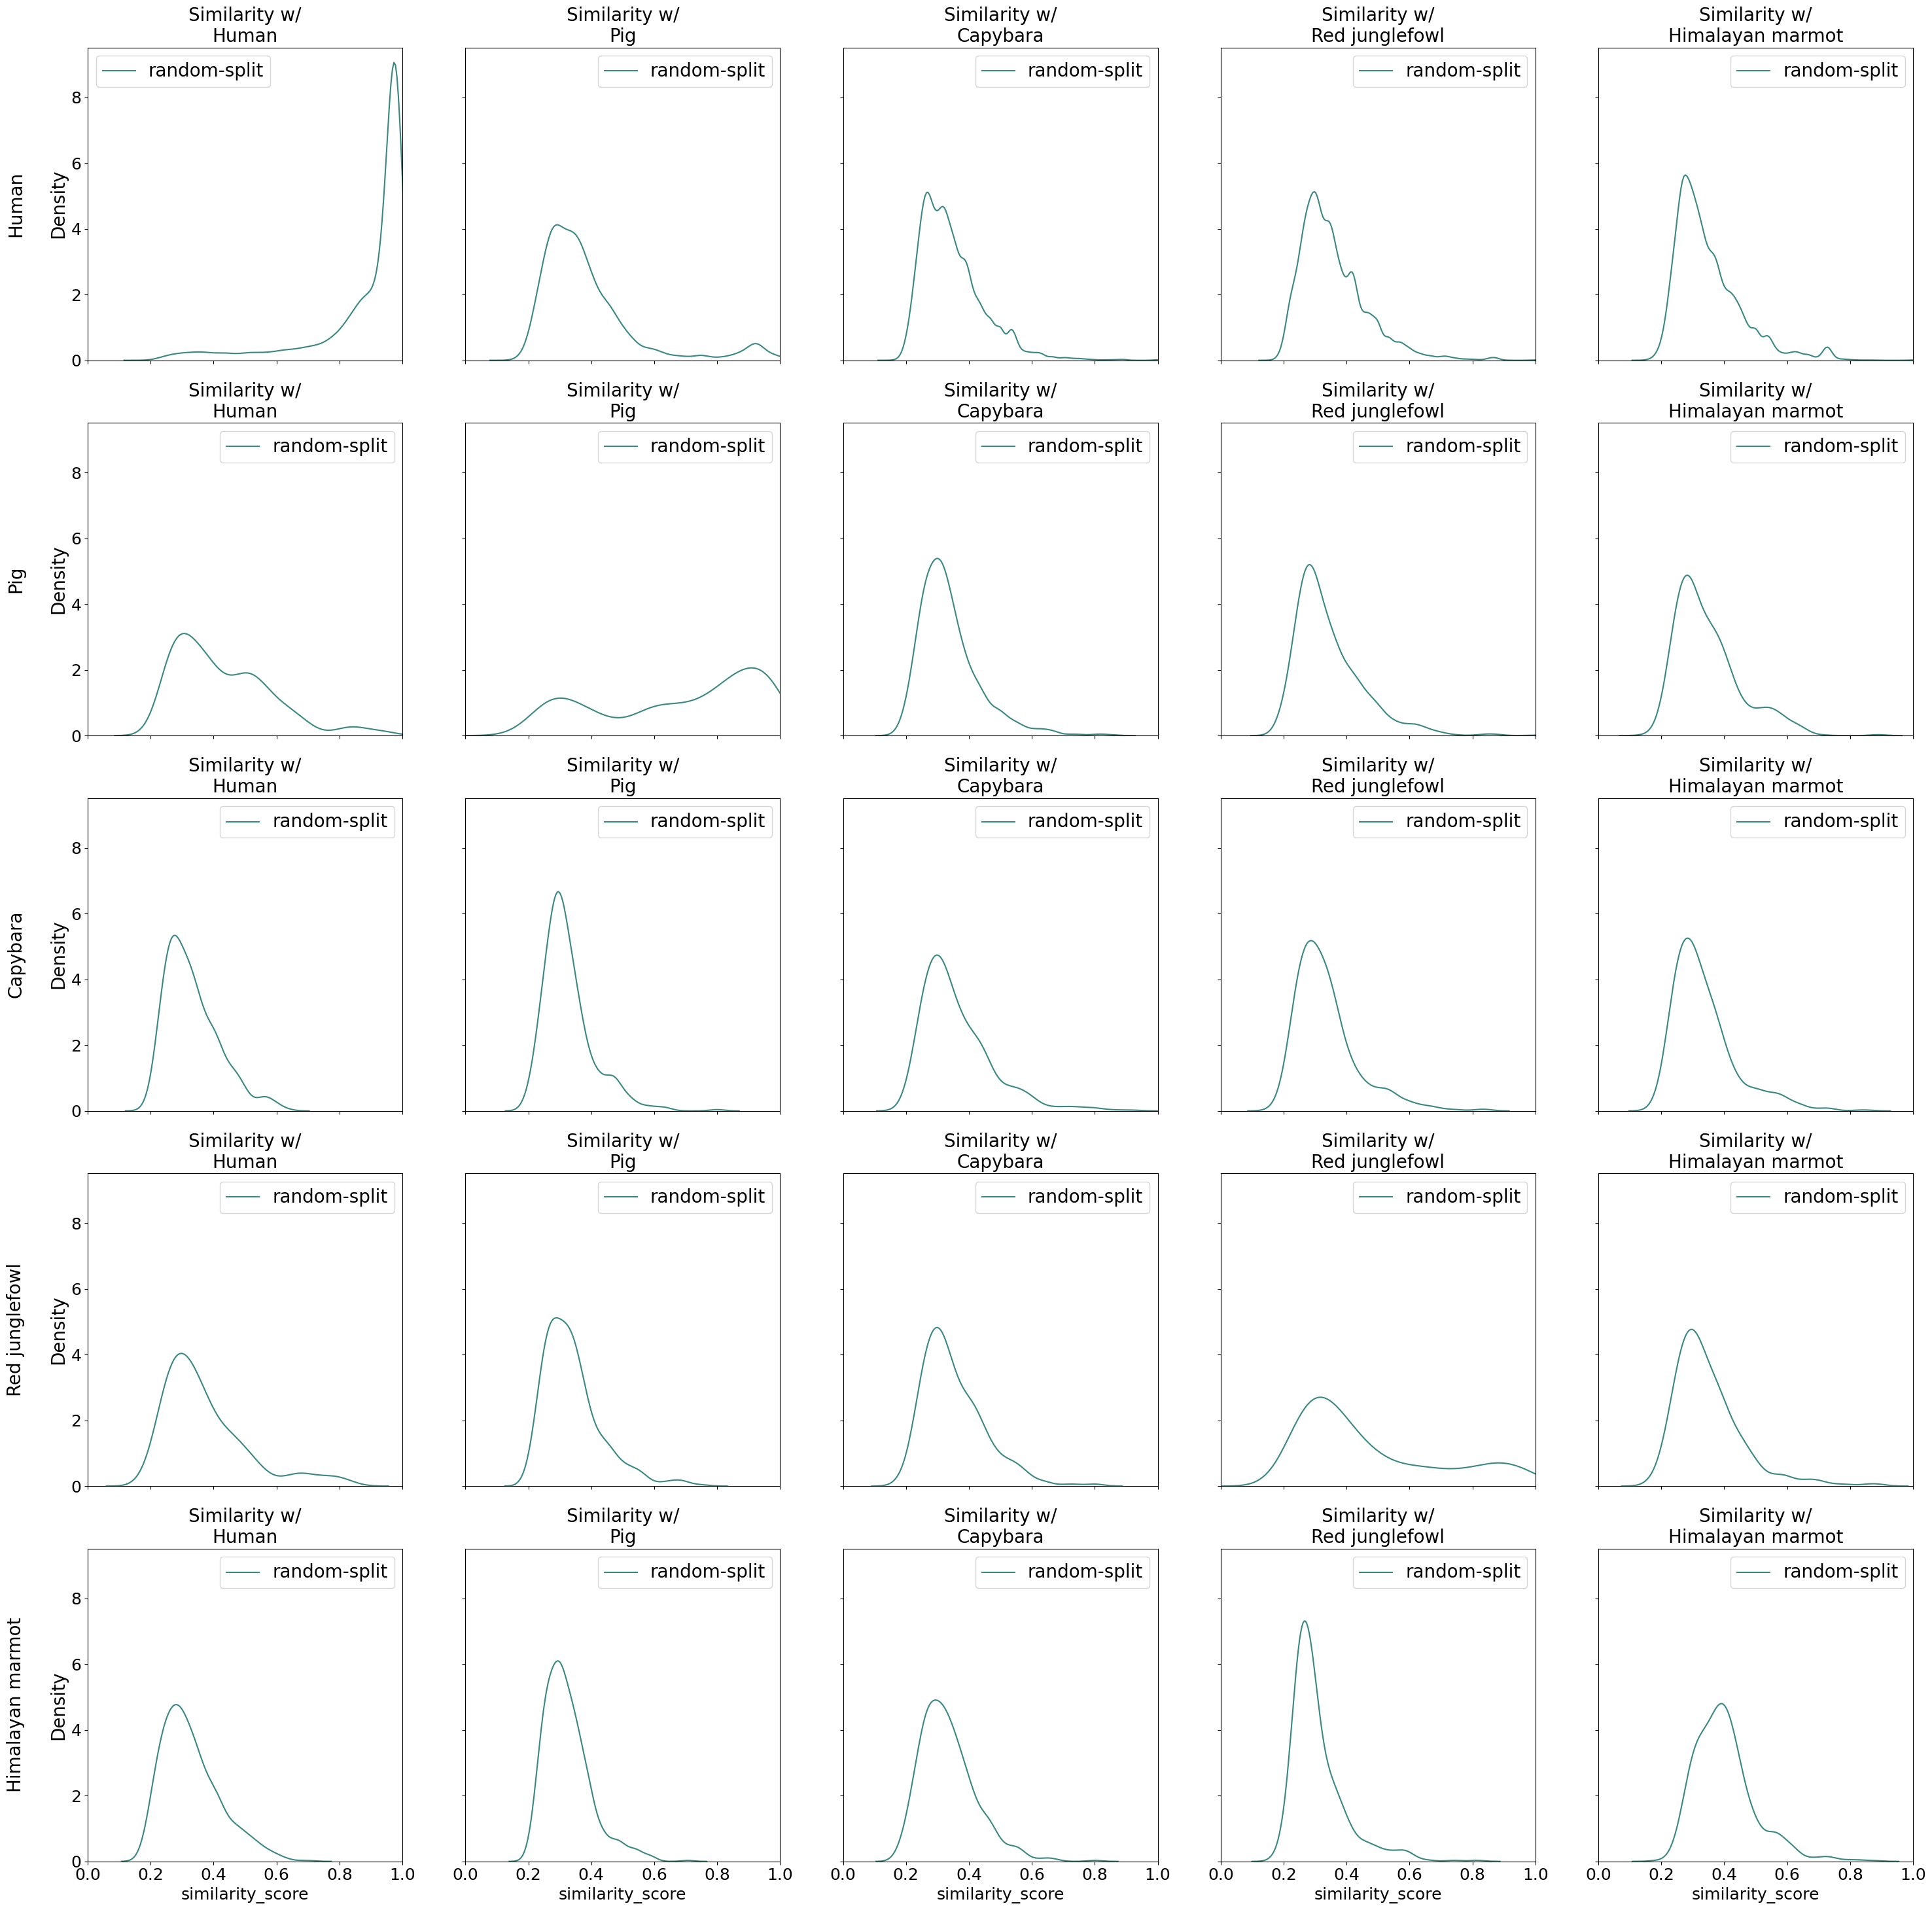

In [19]:
sequence_similarity_filepaths = {
    "random-split": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260528/host_multi/random_split/homology/virus_host_tax_id_multi_blast_blast_similarity_scores.csv"),
}
classes = ["Human", "Pig", "Capybara", "Red junglefowl", "Himalayan marmot"]

similarity_df = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_tax_id")

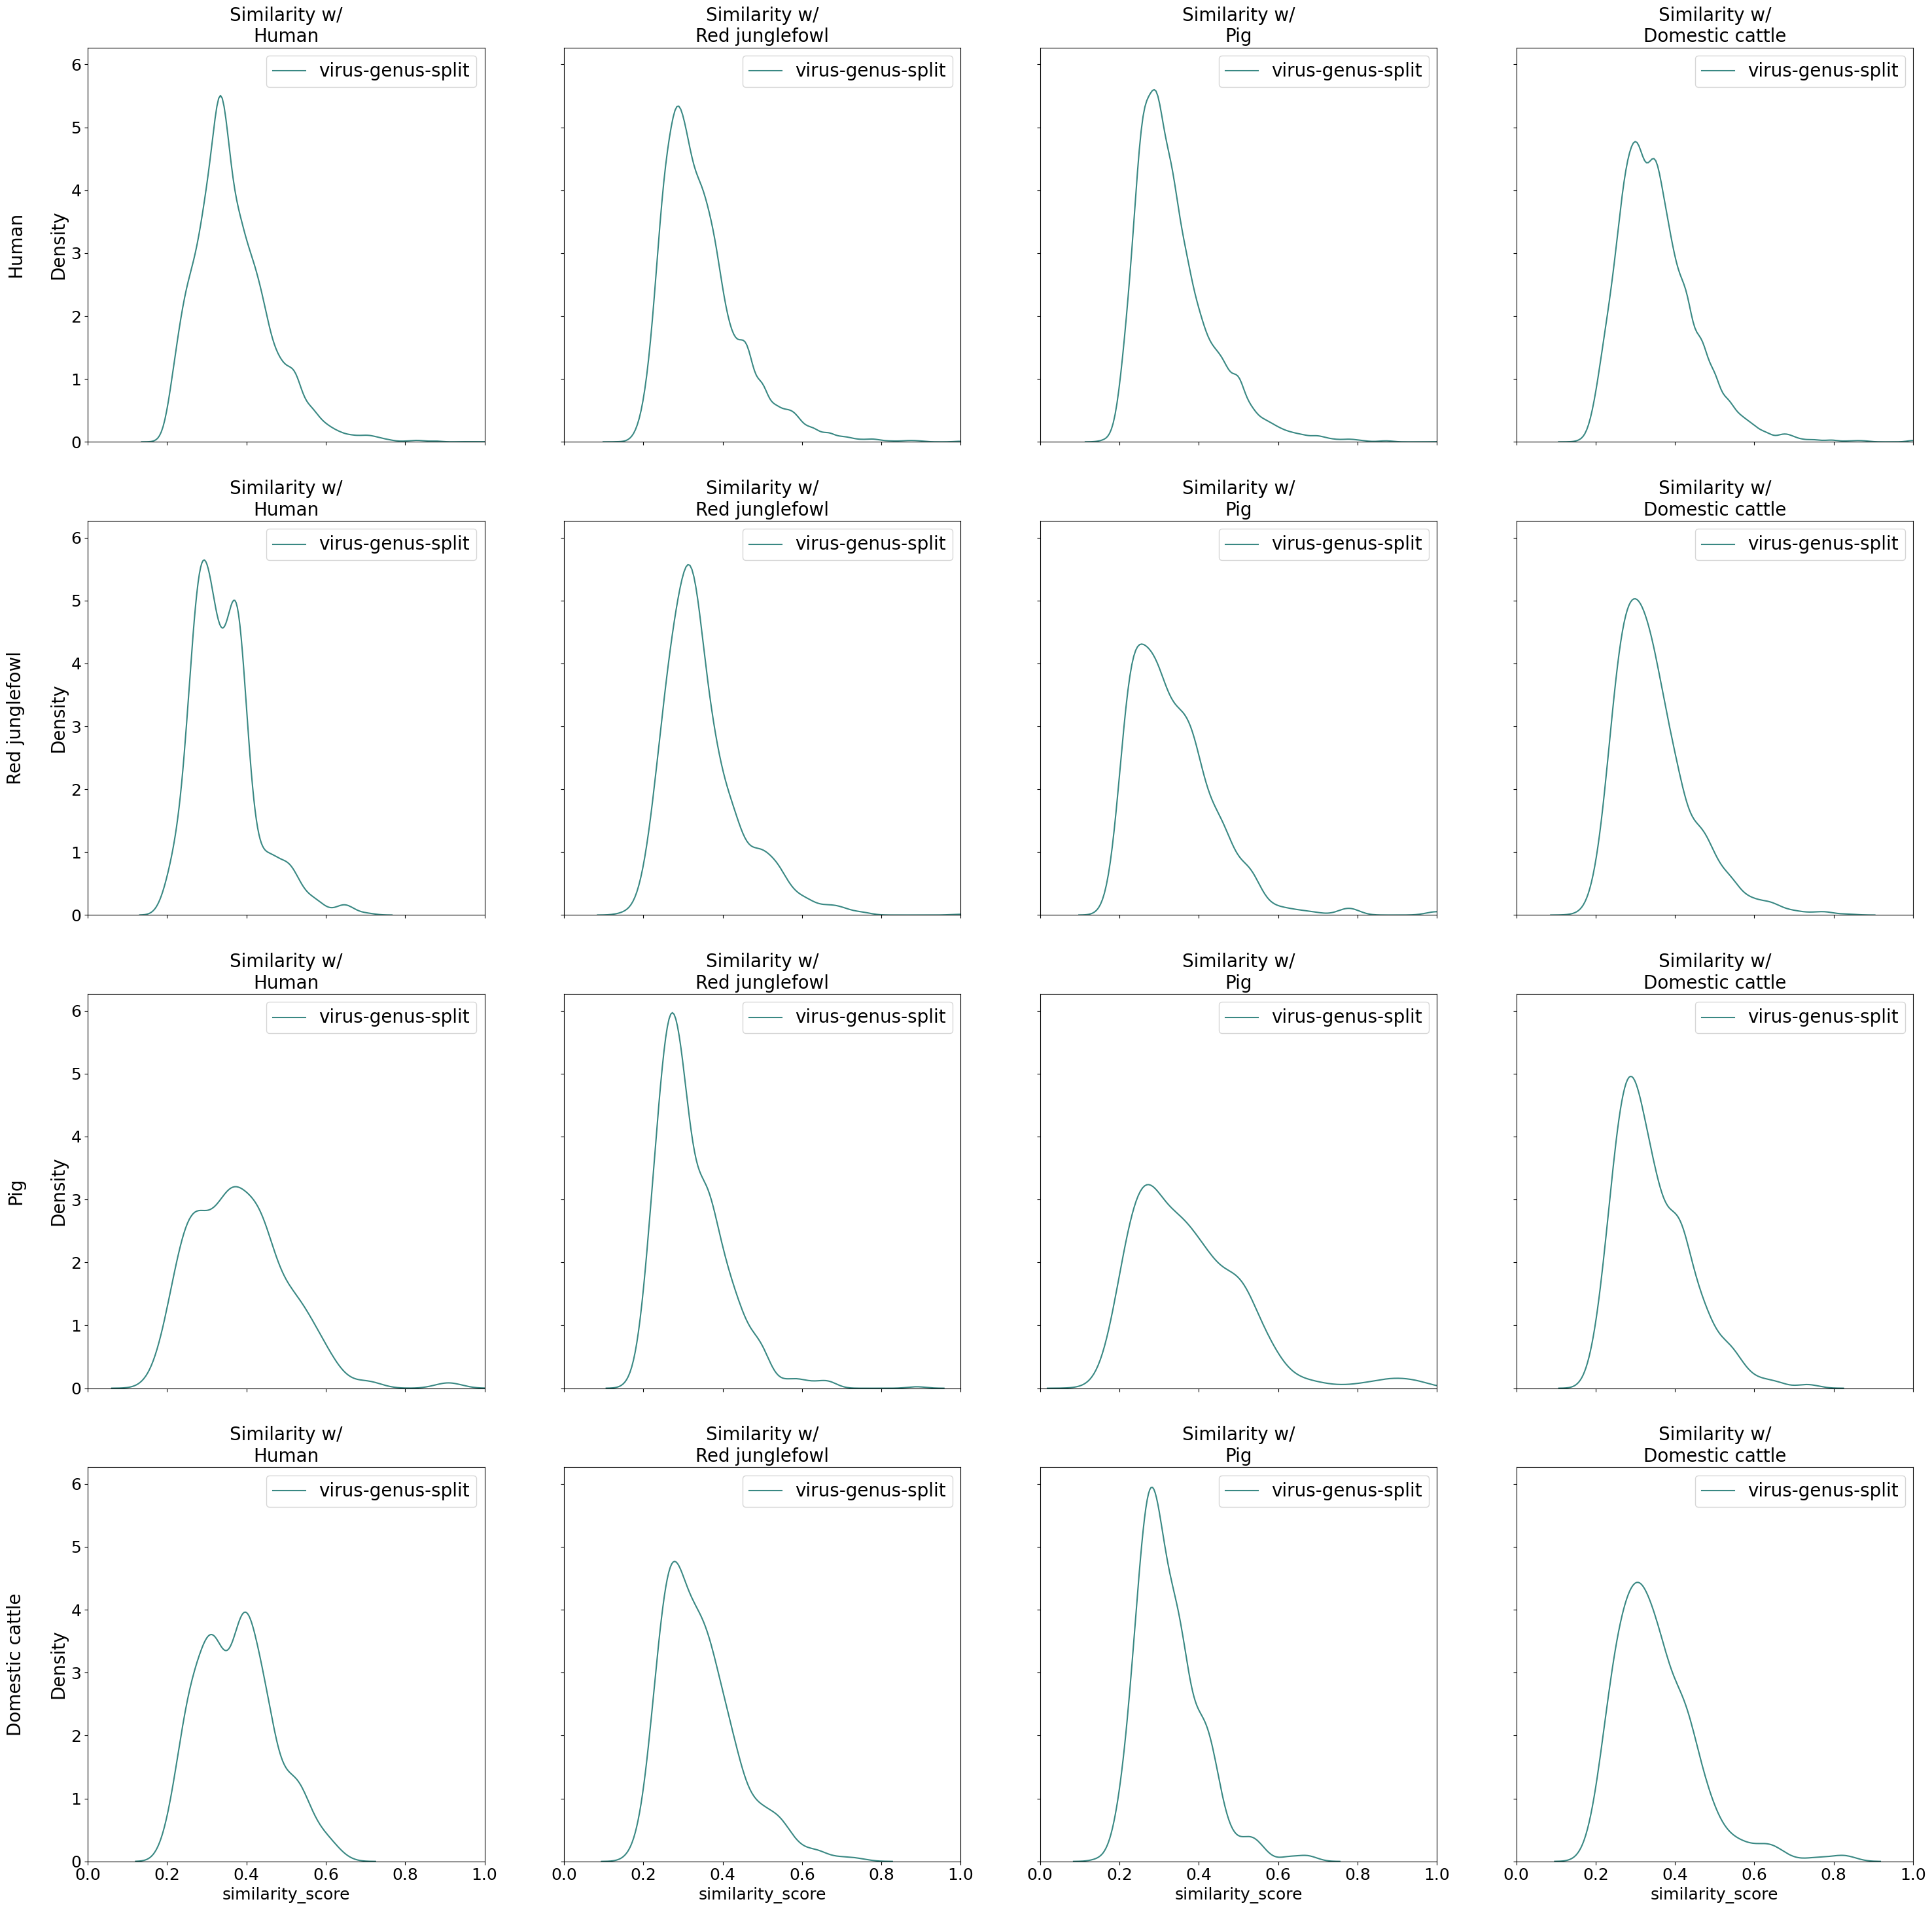

In [28]:
classes = ["Human", "Red junglefowl", "Pig", "Domestic cattle"]

sequence_similarity_filepaths = {
    "virus-genus-split": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_virus_genus_host_species_vertebrates_non_idv_t0.01_c4_seq_len_in_99percentile/20260528/host_multi/virus_genus_split/homology/virus_host_tax_id_multi_blast_blast_similarity_scores.csv"),
}

similarity_df = analyze_sequence_similarity(sequence_similarity_filepaths, classes, label_col="virus_host_tax_id")